In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [453]:
from google.colab import files

uploaded = files.upload()


Saving Sales_Analysis_Dataset.xlsx to Sales_Analysis_Dataset (32).xlsx


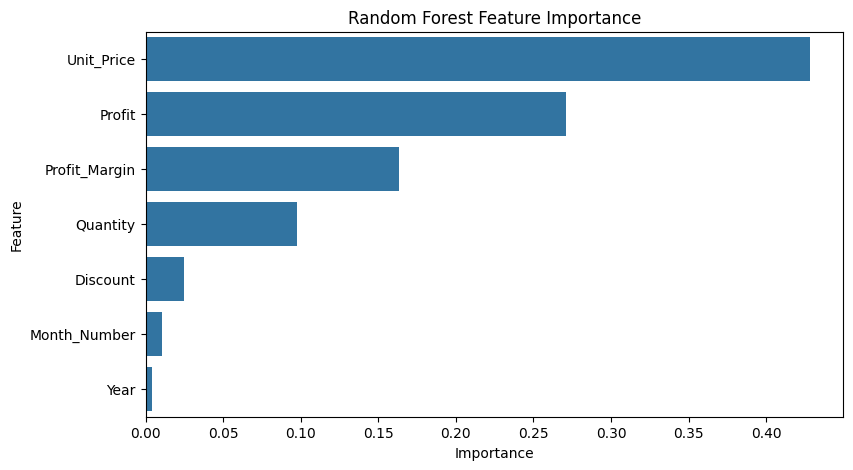

In [454]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [455]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Unit_Price,0.428082
3,Profit,0.270968
6,Profit_Margin,0.163383
0,Quantity,0.097482
2,Discount,0.025029
5,Month_Number,0.010659
4,Year,0.004396


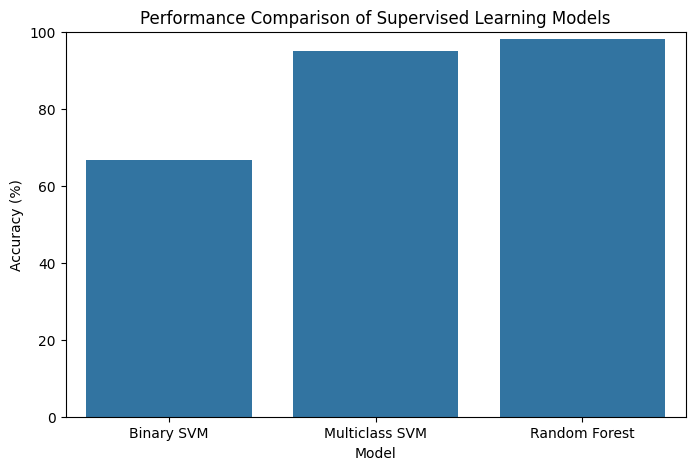

In [456]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy (%)'
)

plt.title('Performance Comparison of Supervised Learning Models')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.show()

In [457]:
results = pd.DataFrame({
    'Model': [
        'Binary SVM',
        'Multiclass SVM',
        'Random Forest'
    ],
    'Accuracy (%)': [
        binary_accuracy * 100,
        multi_accuracy * 100,
        rf_accuracy * 100
    ]
})

results['Accuracy (%)'] = results['Accuracy (%)'].round(2)

display(results)

,Model,Accuracy (%)
0,Binary SVM,66.7
1,Multiclass SVM,95.1
2,Random Forest,98.0


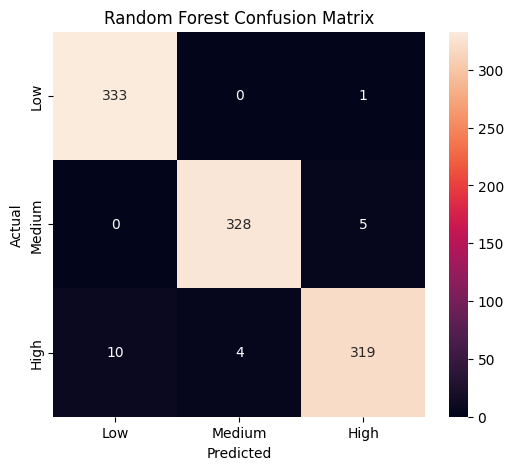

In [458]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [459]:
print("Random Forest Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Classification Report
              precision    recall  f1-score   support

        High       0.97      1.00      0.98       334
         Low       0.99      0.98      0.99       333
      Medium       0.98      0.96      0.97       333

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [460]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 98.0 %


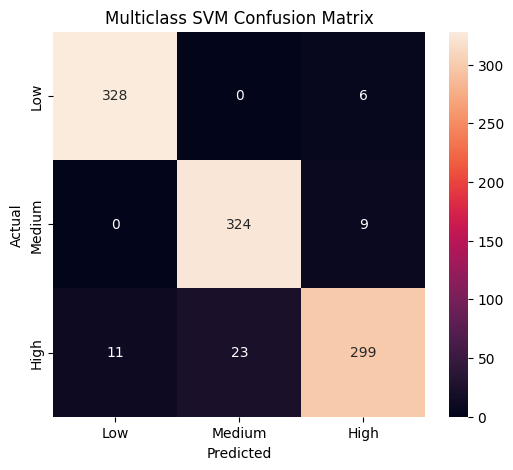

In [461]:
cm_multi = confusion_matrix(
    y_test,
    y_pred_multi
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Multiclass SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [462]:
print("Multiclass SVM Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_multi
))

Multiclass SVM Classification Report
              precision    recall  f1-score   support

        High       0.97      0.98      0.97       334
         Low       0.93      0.97      0.95       333
      Medium       0.95      0.90      0.92       333

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [463]:
scaler_multi = StandardScaler()

X_train_scaled = scaler_multi.fit_transform(X_train)
X_test_scaled = scaler_multi.transform(X_test)

svm_multi = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_multi.fit(
    X_train_scaled,
    y_train
)

y_pred_multi = svm_multi.predict(
    X_test_scaled
)

multi_accuracy = accuracy_score(
    y_test,
    y_pred_multi
)

print(
    "Multiclass SVM Accuracy:",
    round(multi_accuracy * 100, 2),
    "%"
)

Multiclass SVM Accuracy: 95.1 %


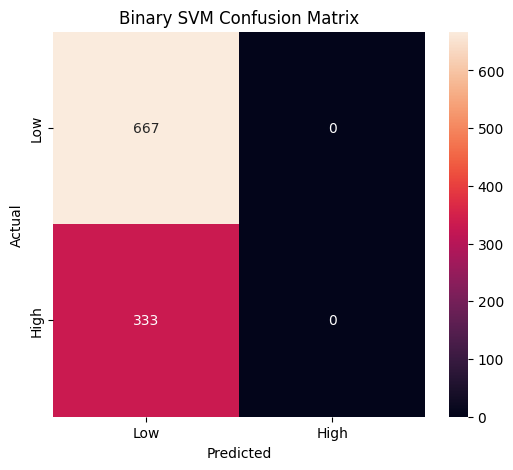

In [464]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_b,
    y_pred_binary
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High']
)

plt.title('Binary SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [465]:
print("Binary SVM Classification Report")
print("=" * 50)

print(classification_report(
    y_test_b,
    y_pred_binary
))

Binary SVM Classification Report
              precision    recall  f1-score   support

        High       0.67      1.00      0.80       667
         Low       0.00      0.00      0.00       333

    accuracy                           0.67      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.44      0.67      0.53      1000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [466]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

scaler = StandardScaler()

X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)

svm_binary = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_binary.fit(X_train_b_scaled, y_train_b)

y_pred_binary = svm_binary.predict(X_test_b)

binary_accuracy = accuracy_score(
    y_test_b,
    y_pred_binary
)

print("Binary SVM Accuracy:",
      round(binary_accuracy * 100, 2), "%")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Binary SVM Accuracy: 66.7 %


In [467]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training samples:", len(X_train_b))
print("Testing samples:", len(X_test_b))

Training samples: 4000
Testing samples: 1000


In [468]:
# Create binary target
y_binary = y.map({
    'Low': 'Low',
    'Medium': 'High',
    'High': 'High'
})

print(y_binary.value_counts())

Sales_Category
High    3333
Low     1667
Name: count, dtype: int64


In [469]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 7)
Testing data: (1000, 7)


In [470]:
df['Sales_Category'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

X = df[
    [
        'Quantity',
        'Unit_Price',
        'Discount',
        'Profit',
        'Year',
        'Month_Number',
        'Profit_Margin'
    ]
]

y = df['Sales_Category']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 7)
y shape: (5000,)


In [471]:
df['Sales_Category'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("Sales_Category created successfully!")
print(df['Sales_Category'].value_counts())

Sales_Category created successfully!
Sales_Category
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64


In [472]:
df = pd.read_excel(file_name, sheet_name='Sales_Data')

print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']


In [473]:
df['Sales_Category'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(df['Sales_Category'].value_counts())

Sales_Category
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64


In [474]:
df = pd.read_excel(file_name, sheet_name='Sales_Data')

print("Dataset loaded successfully")
print(df.shape)
display(df.head())

Dataset loaded successfully
(5000, 22)


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02


In [475]:
display(df.head(10))

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02
5,ORD02880,2023-01-02,Aditya Rao,Corporate,Ball Pen Set,Office Supplies,Stationery,North,Jaipur,5,...,37.91,9.67,UPI,2023,Jan,1,Q1,25.51,NaN,5.119127e-02
6,ORD03151,2023-01-02,Aarav Mehta,Consumer,Ring Binder,Office Supplies,Binders,North,Delhi,2,...,12.64,1.84,Credit Card,2023,Jan,1,Q1,14.56,NaN,NaN
7,ORD03453,2023-01-02,Kunal Bansal,Corporate,Mechanical Keyboard,Technology,Accessories,South,Bengaluru,2,...,139.55,15.06,Debit Card,2023,Jan,1,Q1,10.79,NaN,NaN
8,ORD04553,2023-01-02,Rahul Verma,Consumer,Stapler,Office Supplies,Stationery,North,Chandigarh,3,...,26.73,5.64,UPI,2023,Jan,1,Q1,21.10,NaN,NaN
9,ORD04642,2023-01-02,Kunal Bansal,Consumer,Ball Pen Set,Office Supplies,Stationery,West,Mumbai,2,...,16.31,4.56,Net Banking,2023,Jan,1,Q1,27.96,NaN,NaN


In [476]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Data types:
Order_ID                    object
Order_Date          datetime64[ns]
Customer_Name               object
Customer_Segment            object
Product_Name                object
Category                    object
Sub_Category                object
Region                      object
City                        object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Sales                      float64
Profit                     float64
Payment_Method              object
Year                         int64
Month                       object
Month_Number                 int64
Quarter                     object
Profit_Margin              float64
Unnamed: 20                float64
Unnamed: 21                float64
dtype: object

Missing values:
Order_ID               0
Order_Date             0
Customer_Name          0
Customer_Segment       0
Product_Name           0
Category               0
Sub_Category           0
Region      

In [477]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
Order_ID
Order_Date
Customer_Name
Customer_Segment
Product_Name
Category
Sub_Category
Region
City
Quantity
Unit_Price
Discount
Sales
Profit
Payment_Method
Year
Month
Month_Number
Quarter
Profit_Margin
Unnamed: 20
Unnamed: 21


In [478]:
import pandas as pd

# Show the first 15 rows exactly as they appear in Excel
raw_df = pd.read_excel(file_name, header=None)

print("Excel shape:", raw_df.shape)

display(raw_df.head(15))

Excel shape: (14, 2)


,0,1
0,NaN,NaN
1,NaN,NaN
2,Row Labels,Sum of Sales
3,Apple iPhone 13,458221.37
4,HP Pavilion 15,422573.72
5,Lenovo IdeaPad 3,335237.73
6,Conference Table,294556.84
7,Samsung Galaxy A54,216268.31
8,HP Laser Printer,148049.76
9,Study Desk,130845.84


In [479]:
file_name = next(iter(uploaded))

df = pd.read_excel(file_name)

print("Excel file loaded successfully!")
print("File:", file_name)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Excel file loaded successfully!
File: Sales_Analysis_Dataset (32).xlsx
Rows: 13
Columns: 2


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Row Labels,Sum of Sales
2,Apple iPhone 13,458221.37
3,HP Pavilion 15,422573.72
4,Lenovo IdeaPad 3,335237.73


In [480]:
excel = pd.ExcelFile(file_name)

print("Sheets in this Excel file:")
print(excel.sheet_names)

Sheets in this Excel file:
['Sheet1', 'Sales_Data', 'Project_Summary']


In [481]:
import pandas as pd

df = pd.read_excel(file_name, sheet_name='Sales_Data')

print("Sales_Data loaded successfully!")
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())

Sales_Data loaded successfully!
Shape: (5000, 22)

Column Names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02
